# Langchain - Core components

<div class="alert alert-block alert-info">

Resources:

- https://docs.langchain.com/oss/python/langchain/overview
- https://www.youtube.com/watch?v=vzJOAnwIokM
- https://www.youtube.com/watch?v=J7j5tCB_y4w

</div>

In [2]:
"""                     Import libraries.                       """
import os
import requests
from dotenv import load_dotenv
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from langchain.agents import create_agent
from IPython.display import display

In [3]:

"""                     Setup.                       """
# Load environment variables from .env file.
load_dotenv()
os.environ["NVIDIA_API_KEY"] = os.getenv("NVIDIA_API_KEY")
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

# Create the model_llm instance with NVIDIA model
model_llm = ChatNVIDIA(model="meta/llama-3.1-405b-instruct")

```python
ChatNVIDIA.get_available_models()
# model_llm.get_available_models()
```

## 1. Agents

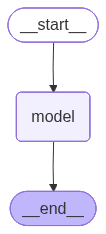

In [3]:
agent = create_agent(
    model=model_llm,
    tools=[],
    system_prompt="You are a helpful assistant."
)
display(agent)

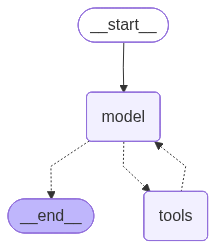

In [4]:
# Define a simple tool/function to get the weather for a city.
'''
def get_weather(city: str) -> str:
    """Get the current weather for a given city."""
    response = requests.get(f"https://wttr.in/{city}?format=j1")
    return response.json()
'''
def get_weather(city: str) -> str:
    """Get the current weather for a given city."""
    response = f"The current weather in {city} is sunny with a temperature of 25°C."
    return response

# Create an agent with the weather tool.
agent_with_tool = create_agent(
    model=model_llm,
    tools=[get_weather],
    system_prompt="You are a helpful weather assistant, who always cracks jokes and is humrous while remaining helpful."
)
display(agent_with_tool)

In [5]:
# Run the agent with a query.
response = agent_with_tool.invoke({
    "messages": [
        {
            "role": "user",
            "content": "What is the current weather in New York?"
        }
    ]
})

print(response)
print(f"\n{'=' * 100}\n")
print(response['messages'][-1].content)

{'messages': [HumanMessage(content='What is the current weather in New York?', additional_kwargs={}, response_metadata={}, id='d894117e-83ff-4c3e-95fb-b8c86a56c571'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'chatcmpl-tool-9e99aea708bbc973', 'type': 'function', 'function': {'name': 'get_weather', 'arguments': '{"city": "New York"}'}}]}, response_metadata={'role': 'assistant', 'content': None, 'refusal': None, 'annotations': None, 'audio': None, 'function_call': None, 'tool_calls': [{'id': 'chatcmpl-tool-9e99aea708bbc973', 'type': 'function', 'function': {'name': 'get_weather', 'arguments': '{"city": "New York"}'}}], 'reasoning': None, 'reasoning_content': None, 'token_usage': {'prompt_tokens': 203, 'total_tokens': 222, 'completion_tokens': 19, 'prompt_tokens_details': None}, 'finish_reason': 'tool_calls', 'model_name': 'meta/llama-3.1-405b-instruct'}, id='lc_run--019d2c1a-f15d-7f31-8422-9207ce534f1e-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'New Yor

In [6]:
# Alternate way to run the agent with a query.
response = agent_with_tool.invoke(
    {
        "messages": "What is the current weather in New York?"
    }
)
print(response['messages'][-1].content)

The current weather in New York is sunny with a temperature of 25°C.


## 2. Models

LLMs are powerful AI tools that can interpret and generate text like humans. They’re versatile enough to write content, translate languages, summarize, and answer questions without needing specialized training for each task.

In addition to text generation, many models support:

- `Tool calling` - calling external tools (like databases queries or API calls) and use results in their responses.
- `Structured output` - where the model’s response is constrained to follow a defined format.
- `Multimodality` - process and return data other than text, such as images, audio, and video.
- `Reasoning` - models perform multi-step reasoning to arrive at a conclusion.

`Models` are the reasoning engine of agents. They drive the agent’s decision-making process, determining which tools to call, how to interpret results, and when to provide a final answer.

Models can be utilized in two ways:

- `With agents` - Models can be dynamically specified when creating an agent.
- `Standalone` - Models can be called directly (outside of the agent loop) for tasks like text generation, classification, or extraction without the need for an agent framework.

Key methods of a `model` class object are `invoke`, `stream` and `batch`.

### 2.1. Invocation

#### 2.1.1. Invoke

The most straightforward way to call a model is to use `invoke()` with a single message or a list of messages.

In [11]:
from langchain.chat_models import init_chat_model

# Initialize different chat models from various providers.
"""
model = init_chat_model(model="nvidia:meta/llama-3.1-405b-instruct")
model = init_chat_model(model="groq:llama-3.3-70b-versatile")
"""
# model = init_chat_model(model="google_genai:gemini-2.5-flash-lite")
model = init_chat_model(model="google_genai:gemini-2.5-flash")

# Invoke the models with a simple query.
query = "What is the capital of France?"
response = model.invoke(query)

# Print the responses.
print(f"Response:    {response.content}")

Response:    The capital of France is **Paris**.


In [12]:
from langchain_google_genai import ChatGoogleGenerativeAI

# Directly initialize and invoke the models.
"""
from langchain_groq import ChatGroq

model = ChatNVIDIA(model="meta/llama-3.1-405b-instruct")
model = ChatGroq (model="llama-3.3-70b-versatile")
"""
# model = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

# Invoke the models with a simple query.
query = "What is the capital of Australia?"
response = model.invoke(query)

# Print the responses.
print(f"Response:    {response.content}")

Response:    The capital of Australia is **Canberra**.


Parameters

A chat model takes parameters that can be used to configure its behavior. he full set of supported parameters varies by model and provider, but standard ones include `model`, `api_key`, `temperature`, `max_tokens`, `timeout`and `max_retries`.

Using `init_chat_model`, pass these parameters as inline `**kwargs`:

```python
model = init_chat_model(
    "claude-sonnet-4-6",
    # kwargs passed to the model.
    temperature=0.7,
    timeout=30,
    max_tokens=1000,
    max_retries=6,  # default
)
```

#### 2.1.2. Stream

Most models can stream their output content while it is being generated. By displaying output progressively, streaming significantly improves user experience, particularly for longer responses.

Calling `stream()` returns an iterator that yields output chunks as they are produced. 

In [14]:
model = ChatNVIDIA(model="meta/llama-3.1-405b-instruct")

# Model response with streaming response.
query = "Tell me a joke."
model.invoke(query)
# model.stream(query)

# basic text streaming.
for chunk in model.stream(query):
    print(chunk.content, end="|", flush=True)

print(f"\n{'='*100}\n")

# Stream tool calls, reasoning and other contents.
for chunk in model.stream(query):
    for block in chunk.content_blocks:
        if block["type"] == "reasoning" and (reasoning := block.get("reasoning")):
            print(f"Reasoning: {reasoning}")
        elif block["type"] == "tool_call_chunk":
            print(f"Tool call chunk: {block}")
        elif block["type"] == "text":
            print(block["text"])
        else:
            pass

|A| man| walked| into| a| library| and| asked| the| librarian|,| "|Do| you| have| any| books| on| Pav|lov|'s| dogs| and| Sch|r|ö|d|inger|'s| cat|?"

|The| librarian| replied|,| "|It| rings| a| bell|,| but| I|'m| not| sure| if| it|'s| here| or| not|."||||

A
 man
 walked
 into
 a
 library
 and
 asked
 the
 librarian
,
 "
Do
 you
 have
 any
 books
 on
 Pav
lov
's
 dogs
 and
 Sch
r
ö
d
inger
's
 cat
?"
 


The
 librarian
 replied
,
 "
It
 rings
 a
 bell
,
 but
 I
'm
 not
 sure
 if
 it
's
 here
 or
 not
."


As opposed to `invoke()`, which returns a single `AIMessage` after the model has finished generating its full response, `stream()` returns multiple `AIMessageChunk` objects, each containing a portion of the output text. Importantly, each chunk in a stream is designed to be gathered into a full message via summation:

```python
full = None  # None | AIMessageChunk
for chunk in model.stream("What color is the sky?"):
    full = chunk if full is None else full + chunk
    print(full.text)

print(f"\n{'='*100}\n")
print(full.content_blocks)
```

#### 2.1.3. Batch

Batching a collection of independent requests to a model can significantly improve performance and reduce costs, as the processing can be done in parallel.

In [15]:
# Model response with batch queries.
queries = [
    "What is large language model?", 
    "What is AI?", 
    "What is the meaning of life?"
]
responses = model.batch(queries)
for i, response in enumerate(responses):
    print(f"Query: {queries[i]}\nResponse: {response.content}\n\n{'=' * 100}\n")

Query: What is large language model?
Response: A large language model (LLM) is a type of artificial intelligence (AI) model that is designed to process and understand human language at a large scale. It is a deep learning model that is trained on vast amounts of text data, which enables it to learn patterns, relationships, and structures of language.

Large language models are typically based on transformer architecture, which is a type of neural network designed specifically for natural language processing (NLP) tasks. These models are trained using a technique called masked language modeling, where some of the words in the input text are randomly replaced with a mask token, and the model is trained to predict the original word.

The key characteristics of large language models are:

1. **Size**: They are trained on massive amounts of text data, often billions of words or more.
2. **Complexity**: They have millions or billions of parameters, which are the internal variables that the m

By default, `batch()` will only return the final output for the entire batch. If you want to receive the output for each individual input as it finishes generating, you can stream results with `batch_as_completed()`.

```python
responses = model.batch_as_completed(queries)
for i, response in enumerate(responses):
    print(f"Query: {queries[i]}\nResponse: {response}\n\n{'=' * 100}\n")
```

When processing a large number of inputs using `batch()` or `batch_as_completed()`, you may want to control the maximum number of parallel calls. This can be done by setting the `max_concurrency` attribute in the `RunnableConfig` dictionary.

```python
responses = model.batch(
    inputs=queries,
    config={
        'max_concurrency':2,  # limit to 2 parallel calls
    }
)
for i, response in enumerate(responses):
    print(f"Query: {query[i]}\nResponse: {response.content}\n\n{'=' * 100}\n")
```

### 2.2. Tool calling

Models can request to call tools that perform tasks such as fetching data from a database, searching the web, or running code. Tools are pairings of:

- A `schema`, including the name of the tool, a description, and/or argument definitions (often a JSON schema)
- A `function` or coroutine to execute.

Here’s the basic tool calling flow between a user and a model:

<div>
<img src="../../docs/i-tutorials/i-lc-tools.png" width="800"/>
</div>


```python
from IPython.display import Image, display
display(Image('docs/i-tutorials/i-lc-tools.png', width=800))
```

To make tools that you have defined available for use by a model, you must bind them using `bind_tools`. In subsequent invocations, the model can choose to call any of the bound tools as needed.

Some model providers offer built-in tools that can be enabled via model or invocation parameters (e.g. `ChatOpenAI`, `ChatAnthropic`).

Either have docstring in the function definition or use the @tool decorator to add description and metadata to the tool.

```python
@tool('get_weather', description="Get the current weather for a given city.", return_direct=False)
def get_weather(city: str) -> str:
    '''Get the current weather for a given city.'''
    response = requests.get(f"https://wttr.in/{city}?format=j1")
    return response.json()
```

In [42]:
from langchain.tools import tool

# Define a tool/function to get the weather for a city.
@tool
def get_weather(location: str) -> str:
    """Get the weather at a location."""
    return f"It's sunny in {location}."

# Bind the tool to the model and invoke it with a query that requires the tool.
model_with_tools = model.bind_tools(tools=[get_weather])

response = model_with_tools.invoke("What's the weather like in Boston?")
print(response)
print(f"\n{'=' * 100}\n")

for tool_call in response.tool_calls:
    # View tool calls made by the model.
    print(f"Tool: {tool_call['name']}")
    print(f"Args: {tool_call['args']}")

content='' additional_kwargs={'tool_calls': [{'id': '4etjkvm9e', 'function': {'arguments': '{"location":"Boston"}', 'name': 'get_weather'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 220, 'total_tokens': 234, 'completion_time': 0.044292908, 'completion_tokens_details': None, 'prompt_time': 0.013185261, 'prompt_tokens_details': None, 'queue_time': 0.213758884, 'total_time': 0.057478169}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_e65acd3773', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019d3469-48ed-70c0-b055-ea715f4a3086-0' tool_calls=[{'name': 'get_weather', 'args': {'location': 'Boston'}, 'id': '4etjkvm9e', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 220, 'output_tokens': 14, 'total_tokens': 234}


Tool: get_weather
Args: {'location': 'Boston'}


Below, are some common ways to use tool calling.

- __Tool execution loop__

    When a model returns tool calls, you need to execute the tools and pass the results back to the model. This creates a conversation loop where the model can use tool results to generate its final response. LangChain includes agent abstractions that handle this orchestration for you.

    Here’s a simple example of how to do this:

    ```python
    # Bind (potentially multiple) tools to the model.
    model_with_tools = model.bind_tools([get_weather])

    # Step 1: Model generates tool calls.
    messages = [{"role": "user", "content": "What's the weather in Boston?"}]
    ai_msg = model_with_tools.invoke(messages)
    messages.append(ai_msg)

    # Step 2: Execute tools and collect results
    for tool_call in ai_msg.tool_calls:
        # Execute the tool with the generated arguments
        tool_result = get_weather.invoke(tool_call)
        messages.append(tool_result)

    # Step 3: Pass results back to model for final response.
    final_response = model_with_tools.invoke(messages)
    print(final_response.text)
    # "The current weather in Boston is 72°F and sunny."

    print(f"\n{'='*100}\n")
    print(messages)
    ```

- __Forcing tool calls__

    By default, the model has the freedom to choose which bound tool to use based on the user’s input. However, you might want to force choosing a tool, ensuring the model uses either a particular tool or any tool from a given list:

    ```python
    # Force use of any tool.
    model_with_tools = model.bind_tools([tool_1], tool_choice="any")

    # Force use of specific tool.
    model_with_tools = model.bind_tools([tool_1], tool_choice="tool_1")
    ```

- __Parallel tool calls__

    Many models support calling multiple tools in parallel when appropriate. This allows the model to gather information from different sources simultaneously.

    ```python
    model_with_tools = model.bind_tools([get_weather])

    response = model_with_tools.invoke(
        "What's the weather in Boston and Tokyo?"
    )

    # The model may generate multiple tool calls.
    print(response.tool_calls)
    
    # Execute all tools (can be done in parallel with async).
    results = []
    for tool_call in response.tool_calls:
        if tool_call['name'] == 'get_weather':
            result = get_weather.invoke(tool_call)
        ...
        results.append(result)
    ```

    Most models supporting tool calling enable parallel tool calls by default. Some (including `OpenAI` and `Anthropic`) allow you to disable this feature. To do this, set `parallel_tool_calls=False`.
    
    ```python
    model.bind_tools([get_weather], parallel_tool_calls=False)
    ```

- __Streaming tool calls__

    When streaming responses, tool calls are progressively built through `ToolCallChunk`. This allows you to see tool calls as they’re being generated rather than waiting for the complete response.

    ```python
    for chunk in model_with_tools.stream(
        "What's the weather in Boston and Tokyo?"
    ):
        # Tool call chunks arrive progressively
        for tool_chunk in chunk.tool_call_chunks:
            if name := tool_chunk.get("name"):
                print(f"Tool: {name}")
            if id_ := tool_chunk.get("id"):
                print(f"ID: {id_}")
            if args := tool_chunk.get("args"):
                print(f"Args: {args}")
    ```

    You can accumulate chunks to build complete tool calls.
    
    ```python
    # Accumulate tool calls
    gathered = None
    for chunk in model_with_tools.stream("What's the weather in Boston?"):
        gathered = chunk if gathered is None else gathered + chunk
        print(gathered.tool_calls)
    ```

### 2.2. Structured output

TBC

## 3. Messages

Messages are the fundamental unit of context for models in LangChain. They represent the input and output of models, carrying both the content and metadata needed to represent the state of a conversation when interacting with an LLM.

Messages are objects that contain:

- __👨‍💼Role__ - Identifies the message type (e.g. `system`, `user`)
- __🗂️Content__ - Represents the actual content of the message (like text, images, audio, documents, etc.)
- __🏷️Metadata__ - Optional fields such as response information, message IDs, and token usage

LangChain provides a standard message type that works across all model providers, ensuring consistent behavior regardless of the model being called.

### 3.1. Basic usage

The simplest way to use messages is to create message objects and pass them to a model when invoking.

In [ ]:
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage, SystemMessage

model = init_chat_model(model="groq:llama-3.3-70b-versatile")

system_msg = SystemMessage("You are a helpful assistant.")
human_msg = HumanMessage("Hello, how are you?")

# Use with chat models.
messages = [system_msg, human_msg]
response = model.invoke(messages)  # returns AIMessage
print(f"Response:\n{response}")
print(f"\n{'=' * 100}\n")
print(f"Response content:\n{response.content}")

Response:
content="Hello! I'm doing well, thank you for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm always happy to chat and help with any questions or topics you'd like to discuss. How about you? How's your day going so far?" additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 64, 'prompt_tokens': 47, 'total_tokens': 111, 'completion_time': 0.116569789, 'completion_tokens_details': None, 'prompt_time': 0.00179536, 'prompt_tokens_details': None, 'queue_time': 0.223952498, 'total_time': 0.118365149}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_e65acd3773', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019d3094-97e8-7501-8659-3e84a224413d-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 47, 'output_tokens': 64, 'total_tokens': 111}


Response content:
Hello! I'm doing well, thank you for asking. I'm a la

#### 3.1.1. Text prompts

Text prompts are strings - ideal for straightforward generation tasks where you don’t need to retain conversation history.

Use text prompts when:

- You have a single, standalone request
- You don’t need conversation history
- You want minimal code complexity

In [24]:
response = model.invoke("Write a haiku about spring")
print(f"Response:\n{response}")
print(f"\n{'=' * 100}\n")
print(f"Response content:\n{response.content}")

Response:
content="Blooms of color rise\nGentle breezes whisper sweet\nSpring's warm gentle kiss" additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 41, 'total_tokens': 61, 'completion_time': 0.037810636, 'completion_tokens_details': None, 'prompt_time': 0.012448426, 'prompt_tokens_details': None, 'queue_time': 0.451622935, 'total_time': 0.050259062}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019d3096-18f1-7e81-9412-f1474c1fbfaf-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 41, 'output_tokens': 20, 'total_tokens': 61}


Response content:
Blooms of color rise
Gentle breezes whisper sweet
Spring's warm gentle kiss


#### 3.1.2. Message prompts

You can also pass in a list of messages to the model by providing a list of message objects.

Use message prompts when:

- Managing multi-turn conversations
- Working with multimodal content (images, audio, files)
- Including system instructions

In [25]:
from langchain.messages import SystemMessage, HumanMessage, AIMessage

messages = [
    SystemMessage("You are a poetry expert"),
    HumanMessage("Write a haiku about spring"),
    AIMessage("Cherry blossoms bloom...")
]
response = model.invoke(messages)
print(f"Response:\n{response}")
print(f"\n{'=' * 100}\n")
print(f"Response content:\n{response.content}")

Response:
content=" \nDancing petals soften air \nSpring's sweet gentle kiss" additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 52, 'total_tokens': 65, 'completion_time': 0.044308573, 'completion_tokens_details': None, 'prompt_time': 0.003191241, 'prompt_tokens_details': None, 'queue_time': 0.379833685, 'total_time': 0.047499814}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019d3098-b63d-7882-a841-3b63174486e4-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 52, 'output_tokens': 13, 'total_tokens': 65}


Response content:
 
Dancing petals soften air 
Spring's sweet gentle kiss


#### 3.1.3. Dictionary format

You can also specify messages directly in `OpenAI` chat completions format.

In [27]:
messages = [
    {"role": "system", "content": "You are a poetry expert"},
    {"role": "user", "content": "Write a haiku about spring"},
    {"role": "assistant", "content": "Cherry blossoms bloom..."}
]
response = model.invoke(messages)
print(f"Response:\n{response}")
print(f"\n{'=' * 100}\n")
print(f"Response content:\n{response.content}")

Response:
content=" \nMorning sun's warm gentle kiss \nSpring's sweet gentle dance" additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 52, 'total_tokens': 66, 'completion_time': 0.040541472, 'completion_tokens_details': None, 'prompt_time': 0.005713215, 'prompt_tokens_details': None, 'queue_time': 0.355686878, 'total_time': 0.046254687}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_68f543a7cc', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019d309a-051d-74f3-91bb-4d153b73d8b9-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 52, 'output_tokens': 14, 'total_tokens': 66}


Response content:
 
Morning sun's warm gentle kiss 
Spring's sweet gentle dance


### 3.2. Message types

- __⚙System message__ - Tells the model how to behave and provide context for interactions
- __👨‍💼Human message__ - Represents user input and interactions with the model
- __🤖AI message__ - Responses generated by the model, including text content, tool calls, and metadata
- __🔧Tool message__ - Represents the outputs of tool calls

#### 3.2.1. System message

A `SystemMessage` represent an initial set of instructions that primes the model’s behavior. You can use a system message to set the tone, define the model’s role, and establish guidelines for responses.

In [28]:
# Basic instructions.
system_msg = SystemMessage("You are a helpful coding assistant.")

messages = [
    system_msg,
    HumanMessage("How do I create a REST API?")
]
response = model.invoke(messages)
print(f"Response:\n{response}")
print(f"\n{'=' * 100}\n")
print(f"Response content:\n{response.content}")

Response:
content='Creating a REST API\n====================\n### Overview\n\nA REST (Representational State of Resource) API is an architectural style for designing networked applications. It is based on the idea of resources, which are identified by URIs, and can be manipulated using a fixed set of operations.\n\n### Prerequisites\n\n* Programming language (e.g., Python, Java, Node.js)\n* Web framework (e.g., Flask, Django, Express.js)\n* Database (e.g., MySQL, MongoDB, PostgreSQL)\n\n### Steps to Create a REST API\n\n1. **Define the API Endpoints**: Determine the resources that will be exposed through the API and the operations that can be performed on them.\n2. **Choose a Web Framework**: Select a web framework that supports REST API development, such as Flask or Django for Python, or Express.js for Node.js.\n3. **Design the API Routes**: Define the API routes, including the HTTP methods (GET, POST, PUT, DELETE) and the URI paths.\n4. **Implement the API Endpoints**: Write the code

In [29]:
# Detailed persona.
from langchain.messages import SystemMessage, HumanMessage

system_msg = SystemMessage("""
You are a senior Python developer with expertise in web frameworks.
Always provide code examples and explain your reasoning.
Be concise but thorough in your explanations.
""")

messages = [
    system_msg,
    HumanMessage("How do I create a REST API?")
]
response = model.invoke(messages)
print(f"Response:\n{response}")
print(f"\n{'=' * 100}\n")
print(f"Response content:\n{response.content}")

Response:
content='**Creating a REST API with Python and Flask**\n====================================================\n\n### Introduction\n\nA REST (Representational State of Resource) API is an architectural style for designing networked applications. It\'s based on the idea of resources, which are identified by URIs, and can be manipulated using a fixed set of operations.\n\n### Prerequisites\n\n* Python 3.8 or higher\n* Flask 2.0 or higher\n* A code editor or IDE\n\n### Step 1: Install Flask\n\nTo create a REST API, we\'ll use the Flask web framework. First, install Flask using pip:\n```bash\npip install flask\n```\n### Step 2: Create a New Flask App\n\nCreate a new Python file, e.g., `app.py`, and add the following code:\n```python\nfrom flask import Flask, jsonify, request\n\napp = Flask(__name__)\n\n# Sample in-memory data store\ndata = {\n    1: {"name": "John Doe", "age": 30},\n    2: {"name": "Jane Doe", "age": 25}\n}\n\n# GET /users\n@app.route(\'/users\', methods=[\'GET\'])

#### 3.2.2. Human message

A `HumanMessage` represents user input and interactions. They can contain text, images, audio, files, and any other amount of multimodal content.

_Text content_

In [30]:
# Message object.
response = model.invoke([
  HumanMessage("What is machine learning?")
])

print(f"Response:\n{response}")
print(f"\n{'=' * 100}\n")
print(f"Response content:\n{response.content}")

Response:
content='**Machine Learning Overview**\n================================\n\nMachine learning is a subset of artificial intelligence (AI) that involves the use of algorithms and statistical models to enable machines to perform tasks without being explicitly programmed. It allows systems to learn from data, identify patterns, and make decisions or predictions with minimal human intervention.\n\n**Key Characteristics:**\n\n1. **Data-Driven**: Machine learning relies on large datasets to train and improve the performance of models.\n2. **Self-Improvement**: Machine learning models can adapt and improve over time as they receive new data.\n3. **Pattern Recognition**: Machine learning algorithms can identify complex patterns in data, enabling predictive modeling and decision-making.\n\n**Types of Machine Learning:**\n\n1. **Supervised Learning**: The model is trained on labeled data, where the correct output is already known.\n2. **Unsupervised Learning**: The model is trained on u

In [ ]:
# Using a string as a shortcut for a single HumanMessage.
response = model.invoke("What is machine learning?")

print(f"Response:\n{response}")
print(f"\n{'=' * 100}\n")
print(f"Response content:\n{response.content}")

Response:
content='**Machine Learning Definition**\nMachine learning is a subset of artificial intelligence (AI) that involves the use of algorithms and statistical models to enable machines to learn from data, make decisions, and improve their performance over time without being explicitly programmed.\n\n**Key Characteristics:**\n\n1. **Data-Driven**: Machine learning relies on large amounts of data to learn and make predictions.\n2. **Self-Improvement**: Machine learning models can improve their performance over time through experience and learning from data.\n3. **Pattern Recognition**: Machine learning algorithms can recognize patterns in data and make predictions or decisions based on those patterns.\n4. **Autonomy**: Machine learning models can operate independently, making decisions without human intervention.\n\n**Types of Machine Learning:**\n\n1. **Supervised Learning**: The model learns from labeled data to make predictions.\n2. **Unsupervised Learning**: The model learns fr

_Message metadata_

```python
# Message object with metadata.
human_msg = HumanMessage(
    content="Hello!",
    name="alice",  # optional: identify different users
    id="msg_123",  # optional: unique identifier for tracing
)
```

#### 3.2.3. AI message

An `AIMessage` represents the output of a model invocation. They can include multimodal data, tool calls, and provider-specific metadata that you can later access.

`AIMessage` objects are returned by the model when calling it, which contains all of the associated metadata in the response.

In [33]:
response = model.invoke("Explain AI")
print(f"Response type: {type(response)}")

Response type: <class 'langchain_core.messages.ai.AIMessage'>


Providers weigh/contextualize types of messages differently, which means it is sometimes helpful to manually create a new `AIMessage` object and insert it into the message history as if it came from the model.

In [50]:
from langchain.messages import AIMessage, SystemMessage, HumanMessage

# Create an AI message manually (e.g., for conversation history).
ai_msg = AIMessage("I'd be happy to help you with that question!")

# Add to conversation history.
messages = [
    SystemMessage("You are a helpful assistant"),
    HumanMessage("Can you help me?"),
    ai_msg,  # insert as if it came from the model
    HumanMessage("Great! What's 2+2?")
]

response = model.invoke(messages)
print(f"Response:\n{response}")
print(f"\n{'=' * 100}\n")
print(f"Response content:\n{response.content}")
print(f"\n{'=' * 100}\n")
print(f"Usage metadata:\n{response.usage_metadata}")

Response:
content='The answer to 2+2 is 4. Is there anything else I can help you with?' additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 75, 'total_tokens': 97, 'completion_time': 0.046390027, 'completion_tokens_details': None, 'prompt_time': 0.003915504, 'prompt_tokens_details': None, 'queue_time': 0.218295632, 'total_time': 0.050305531}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_e65acd3773', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019d3482-b36d-76b2-bc38-6b35e68e6847-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 75, 'output_tokens': 22, 'total_tokens': 97}


Response content:
The answer to 2+2 is 4. Is there anything else I can help you with?


Usage metadata:
{'input_tokens': 75, 'output_tokens': 22, 'total_tokens': 97}


_`Tool calls`_

When models make tool calls, they’re included in the `AIMessage`.

Other structured data, such as `reasoning` or `citations`, can also appear in message content.

In [35]:
from langchain.chat_models import init_chat_model

model = init_chat_model(model="groq:llama-3.3-70b-versatile")

def get_weather(location: str) -> str:
    """Get the weather at a location."""
    ...

model_with_tools = model.bind_tools([get_weather])
response = model_with_tools.invoke("What's the weather in Paris?")

for tool_call in response.tool_calls:
    print(f"Tool: {tool_call['name']}")
    print(f"Args: {tool_call['args']}")
    print(f"ID: {tool_call['id']}")

Tool: get_weather
Args: {'location': 'Paris'}
ID: ndnvhs1gc


_`Token usage`_

An `AIMessage` can hold token counts and other usage metadata in its usage_metadata field.

In [37]:
from langchain.chat_models import init_chat_model

model = init_chat_model(model="groq:llama-3.3-70b-versatile")

response = model.invoke("Hello!")
print(f"Response usage metadata:\n{response.usage_metadata}")

Response usage metadata:
{'input_tokens': 37, 'output_tokens': 26, 'total_tokens': 63}


_`Streaming and chunks`_

During streaming, you’ll receive `AIMessageChunk` objects that can be combined into a full message object.

In [39]:
chunks = []
full_message = None
for chunk in model.stream("Hi"):
    chunks.append(chunk)
    print(chunk.text)
    full_message = chunk if full_message is None else full_message + chunk

print(f"\n{'=' * 100}\n")
print(f"Full message:\n{full_message}")


It
's
 nice
 to
 meet
 you
.
 Is
 there
 something
 I
 can
 help
 you
 with
 or
 would
 you
 like
 to
 chat
?




Full message:
content="It's nice to meet you. Is there something I can help you with or would you like to chat?" additional_kwargs={} response_metadata={'model_provider': 'groq', 'finish_reason': 'stop', 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_f8b414701e', 'service_tier': 'on_demand'} id='lc_run--019d30bf-a4b7-71a2-b79b-350f9904e019' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 36, 'output_tokens': 23, 'total_tokens': 59} tool_call_chunks=[] chunk_position='last'


#### 3.2.4. Tool message

For models that support tool calling, AI messages can contain tool calls. Tool messages are used to pass the results of a single tool execution back to the model.

Tools can generate `ToolMessage` objects directly. Below, is a simple example.

In [47]:
from langchain.messages import AIMessage
from langchain.messages import ToolMessage

# After a model makes a tool call
# (Here, we demonstrate manually creating the messages for brevity)
ai_message = AIMessage(
    content=[],
    tool_calls=[{
        "name": "get_weather",
        "args": {"location": "San Francisco"},
        "id": "call_123"
    }]
)

# Execute tool and create result message
weather_result = "Sunny, 72°F"
tool_message = ToolMessage(
    content=weather_result,
    tool_call_id="call_123"  # Must match the call ID
)

# Continue conversation
messages = [
    HumanMessage("What's the weather in San Francisco?"),
    ai_message,  # Model's tool call
    tool_message,  # Tool execution result
]
response = model.invoke(messages)  # Model processes the result
print(f"Model response:\n{response}")
print(f"\n{'=' * 100}\n")
print(f"Model response content:\n{response.content}")

Model response:
content='The current weather in San Francisco is sunny with a temperature of 72°F.' additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 74, 'total_tokens': 91, 'completion_time': 0.060207246, 'completion_tokens_details': None, 'prompt_time': 0.003704757, 'prompt_tokens_details': None, 'queue_time': 0.173235541, 'total_time': 0.063912003}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019d347e-fc90-7dc2-abc9-5fe8c5beec79-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 74, 'output_tokens': 17, 'total_tokens': 91}


Model response content:
The current weather in San Francisco is sunny with a temperature of 72°F.


<div class="alert alert-block alert-info">

### 3.3. Message content

Check <a href="https://docs.langchain.com/oss/python/langchain/messages#message-content">here</a> for more details.

#### 3.3.1. Standard content blocks
#### 3.3.2. Multimodal
#### 3.3.3. Content block reference

</div>

## 4. Tools

Tools extend what agents can do—letting them fetch real-time data, execute code, query external databases, and take actions in the world.

Under the hood, tools are callable functions with well-defined inputs and outputs that get passed to a chat model. The model decides when to invoke a tool based on the conversation context, and what input arguments to provide.

### 4.1. Create tools

#### 4.1.1. Basic tool definition

The simplest way to create a tool is with the `@tool` decorator. By default, the function’s docstring becomes the tool’s description that helps the model understand when to use it.

Type hints are __required__ as they define the tool’s input schema. The docstring should be informative and concise to help the model understand the tool’s purpose.

<div class="alert alert-block alert-warning">

Prefer `snake_case` for tool names (e.g., `web_search` instead of `Web Search`). Some model providers have issues with or reject names containing spaces or special characters with errors. Sticking to alphanumeric characters, underscores, and hyphens helps to improve compatibility across providers.

</div>

In [9]:
from langchain.tools import tool
from langchain.chat_models import init_chat_model

# Define a tool/function to search a database.
@tool
def search_database(query: str, limit: int = 10) -> str:
    """Search the customer database for records matching the query.

    Args:
        query: Search terms to look for
        limit: Maximum number of results to return
    """
    return f"Found {limit} results for '{query}'"

# Create an agent with the search tool.
agent_with_tool = init_chat_model(model="groq:llama-3.3-70b-versatile").bind_tools(tools=[search_database])
response = agent_with_tool.invoke("Search the database for customers in New York.")
print(f"Agent response:\n{response}")

print(f"\n{'=' * 100}\n")
print(f"Agent response content:\n{response.content}")

print(f"\n{'=' * 100}\n")
print(f"Tool: {response.tool_calls[0]['name']}")
print(f"Args: {response.tool_calls[0]['args']}")

Agent response:
content='' additional_kwargs={'tool_calls': [{'id': '8yhs637rn', 'function': {'arguments': '{"limit":10,"query":"New York"}', 'name': 'search_database'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 284, 'total_tokens': 304, 'completion_time': 0.045831025, 'completion_tokens_details': None, 'prompt_time': 0.07731779, 'prompt_tokens_details': None, 'queue_time': 0.26245544, 'total_time': 0.123148815}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019d35bf-8f10-7513-bf49-18587fe8df98-0' tool_calls=[{'name': 'search_database', 'args': {'limit': 10, 'query': 'New York'}, 'id': '8yhs637rn', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 284, 'output_tokens': 20, 'total_tokens': 304}


Agent response content:



Tool: search_database
Args: {'limit

<div class="alert alert-block alert-info">

__*Question: Why is `response.content` empty?*__

__Answer:__
This is expected behaviour. When you use `bind_tools()`, the model generates tool calls but doesn't execute them or produce final text content automatically.

`response.content` is empty because the model is indicating it wants to call the `search_database` tool. The actual information is in `response.tool_calls`.

To get content with an answer, you need to implement the `tool execution loop`.

Alternatively, use LangChain's `create_agent()` which handles the tool execution loop automatically (as shown in your earlier agent examples).

</div>

#### 4.1.2. Customize tool properties

_Custome tool name_

_Custom tool description_



#### 4.1.3. Advanced schema definition

#### 4.1.4. Reserved argument names

### 4.2. Access context

#### 4.2.1. Short-term memory (State)

_Access state_

_Update state_

#### 4.2.2. Context

#### 4.2.3. Long-term memory (Store)

#### 4.2.4. Stream writer

### 4.3. ToolNode

### 4.4. Prebuilt tools

LangChain provides a large collection of prebuilt tools and toolkits for common tasks like web search, code interpretation, database access, and more. These ready-to-use tools can be directly integrated into your agents without writing custom code.

See the <a href="https://docs.langchain.com/oss/python/integrations/tools">tools and toolkits</a> integration page for a complete list of available tools organized by category.

## 5. Structured output